# Solution: Identify land use from aerial images using Convolutional Neural Networks - Part 3

## Transfer Learning using **ResNet-18**

Scroll down below the exercises to see the solutions.


In this notebook, we will explore the advantages of **transfer learning** for the land use classification task. Transfer learning is a powerful technique where a model developed for a specific task is reused as the starting point for a model on a second task. In our case, we'll utilize the pre-trained `ResNet-18` architecture, a renowned CNN model. For image classification tasks, the pre-trained weights are usually available from different versions of the [ImageNet](https://en.wikipedia.org/wiki/ImageNet). This is a large and diverse dataset containing millions of images across thousands of categories.

We will leverage `torchvision.models`, a module within PyTorch's `torchvision` library, to readily obtain pre-trained models and modify them for our purposes. This greatly simplifies the process of applying transfer learning techniques.


<img src="https://www.researchgate.net/profile/Sajid-Iqbal-13/publication/336642248/figure/fig1/AS:839151377203201@1577080687133/Original-ResNet-18-Architecture_W640.jpg" width="1200" alt="The original ResNet-18 architecture">


The walkthrough part of this notebook will show you some code snippets on how to implement the two main approaches for transfer learning:

1. **Fine-tuning all layers**: This approach begins with loading the weights of ResNet18 pre-trained on ImageNet. By fine-tuning all the layers of the architecture, we allow the model to adjust its learned features more precisely to our specific task of land use classification. This method is highly effective when your dataset has some similarities to the original training dataset but still differs in significant ways. Fine-tuning the entire network can lead to better performance as it refines the pre-learned features to be more relevant to the new task. However, this approach requires careful management of the learning rate and other training parameters to ensure that the pre-trained weights are modified appropriately and do not lead to overfitting on the new dataset.

2. **Freezing the feature extraction layers and only fine-tuning the classifier**: In this method, we use the architecture of ResNet18 with its pre-trained weights but *freeze* the feature extraction layers. This means that the weights in these layers, which have already learned to extract general features from a broad dataset, remain unchanged. Only the final classification layers of the network are trained to adapt to the specific land use classification task. This approach is particularly useful when the new dataset is quite similar to the one used for pre-training, or when the availability of data for the new task is limited. By keeping the pre-trained features fixed, the network leverages its prior knowledge, which can lead to faster convergence and less requirement for computational resources. It's a balance between utilizing the strength of the pre-trained model and customizing it to fit the specific nuances of the new dataset.

Alternatively, we could also **use the architecture without pre-trained weights**, that is, initializing the network with random weights. This usually entails that our dataset is significantly different from the dataset used in the original training (e.g., ImageNet). However, we deem that the architecture itself could be a good fit for the problem, at least for initial investigations.

The walktrough will show you how to use `torchvision.models` to load a `ResNet-18` architecture, with and without pre-trained weights, and how we can enforce the freezing of the feature extraction layers. After the walkthrough, you'll be asked to implement the two transfer learning strategies for our case study on land use identification, compare their effectiveness, also with respect to the models you trained in Part 1 and Part 2 of this case study.

## Walkthrough

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from torchsummary import summary

In [ ]:
# Check if CUDA is available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


### Using `ResNet-18` without Pre-trained Weights

To initialize `ResNet-18` model without pre-trained weights we specify `models.resnet18(weights=None)`. The last layer (the fully connected layer) is responsible for classification. We need to find out the number of features extracted by `ResNet-18`, which is essential for adapting this layer for our speecific task. This is obtained from `resnet18.fc.in_features`. For our specific use case of land use identification, we modify the fully connected layer to predict 21 classes (the number of land use categories in our study). This is done by setting `resnet18.fc` to a new `nn.Linear` layer with `num_ftrs` input features and `num_classes` output features.

In [ ]:
# Load the ResNet-18 model
resnet18 = models.resnet18(weights=None)  # This ensures we do not load the pretrained weights

# We need to know the number of features in the last layer of the pretrained model to adapt our classifier.
# These are equal to the number of inputs of the "fully connected" (fc) head of the ResNet-18.
num_ftrs = resnet18.fc.in_features
print(f"The number of features extracted by ResNet-18 are: {num_ftrs}")

# Check the number of output classes of the original ResNet-18
num_outputs = resnet18.fc.out_features
print(f"The original ResNet-18 predicts {num_outputs} classes")

# Modify the fully connected layer to match the number of classes for the land use identification case study
num_classes = 21
resnet18.fc = nn.Linear(num_ftrs, num_classes)
num_outputs = resnet18.fc.out_features
print(f"The modified ResNet-18 predicts {num_outputs} classes")

The number of features extracted by ResNet-18 are: 512
The original ResNet-18 predicts 1000 classes
The modified ResNet-18 predicts 21 classes


 After the modifications, we move the model to the specified device (e.g., GPU or CPU) and print a summary for a given input size. This summary helps in understanding the model’s architecture and the impact of our modifications.
 > Note: Historically, architectures pre-trained on ImageNet are trained on 224x224 RGB input images.


In [ ]:
# Create the final model and print the summary
model = resnet18.to(device)
summary(model, input_size=(3, 224, 224))  # Replace with your input size

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

Finally, we iterate through all the parameters of the model and print their `requires_grad` attribute (i.e., requires the computation of the gradient for backpropagation); `requires_grad` = `True` indicates that the training process will affect the specific layer of parameters. We can see here that all layers will be modified, as expected.


In [ ]:
# Freeze the layers
for param in resnet18.parameters():
    print(param.requires_grad)

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


### Fine-tuning the entire `ResNet-18` with Pre-Trained Weights


To utilize the `ResNet-18` model with pre-trained weights, we first import the weights in our Python environment, and then we assign them to an instance of the `ResNet-18` architecture. `ResNet18_Weights.IMAGENET1K_V1` are the weights obtained after training the model on the 1st version of the IMAGENET1K dataset, which contains over a million images across 100 different classes.


In [ ]:
from torchvision.models import ResNet18_Weights

# Load the ResNet-18 model
resnet18 = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)  # This ensures we load the pretrained weights

# We need to know the number of features in the last layer of the pretrained model to adapt our classifier.
# These are equal to the number of inputs of the "fully connected" (fc) head of the ResNet-18.
num_ftrs = resnet18.fc.in_features
print(f"The number of features extracted by ResNet-18 are: {num_ftrs}")

# Check the number of output classes of the original ResNet-18
num_outputs = resnet18.fc.out_features
print(f"The original ResNet-18 predicts {num_outputs} classes")

# Modify the fully connected layer to match the number of classes for the land use identification case study
num_classes = 21
resnet18.fc = nn.Linear(num_ftrs, num_classes)
num_outputs = resnet18.fc.out_features
print(f"The modified ResNet-18 predicts {num_outputs} classes")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 80.5MB/s]


The number of features extracted by ResNet-18 are: 512
The original ResNet-18 predicts 1000 classes
The modified ResNet-18 predicts 21 classes


The rest is unchanged.

In [ ]:
# Create the final model and print the summary
model = resnet18.to(device)
summary(model, input_size=(3, 224, 224))  # Replace with your input size

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [ ]:
# Freeze the layers
for param in resnet18.parameters():
    print(param.requires_grad)

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


### Freezing the feature extraction layers to only fine-tune the classifier

To freeze all layers of the ResNet model, we need to disable gradient computation for all parameters. This is done by setting `requires_grad` to `False` for all parameters. To ensure that we can still fine-tune the `resnet18.fc` fully connected classifier, we can either add it after freezing the layers, or set `requires_grad=True` afterwards only for this specific layer (as done below).

In [ ]:
# Load the ResNet-18 model
resnet18 = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)  # This ensures we load the pretrained weights

# We need to know the number of features in the last layer of the pretrained model to adapt our classifier.
# These are equal to the number of inputs of the "fully connected" (fc) head of the ResNet-18.
num_ftrs = resnet18.fc.in_features

# Modify the fully connected layer to match the number of classes for the land use identification case study
num_classes = 21
resnet18.fc = nn.Linear(num_ftrs, num_classes)
num_outputs = resnet18.fc.out_features
print(f"The modified ResNet-18 predicts {num_outputs} classes")

# Freeze all the layers
for param in resnet18.parameters():
    param.requires_grad = False

# Unfreeze classifier
for param in resnet18.fc.parameters():
    param.requires_grad = True

# Check that only the last two layers are not frozen (hidden and output layer of the classifier)
for param in resnet18.parameters():
  print(param.requires_grad)

The modified ResNet-18 predicts 21 classes
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
True
True


### Data Normalization to use Pre-trained Model

When fine-tuning the pre-trained architecture on your dataset, it is crucial to apply the same data normalization that was used during the initial training of the network. For models trained on the ImageNet dataset, which includes the standard `ResNet-18` used here, the common practice is to normalize the input data using the *mean* and *standard deviation* of the ImageNet dataset. These values are:

* Mean: [0.485, 0.456, 0.406] for the RGB channels, reespectively;
* Standard Deviation: [0.229, 0.224, 0.225] for the RGB channels, reespectively.


You can implement this normalization in `PyTorch` as part of the data preprocessing pipeline, using `transforms`:

```
# Define the transformation
transform = transforms.Compose([
    ...
    ...
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
```

Also, remember to make sure you input images are 224x224 pixels RGB images.

## Assignments

The instructions below describe the assignments for this notebook. Carrying them out will improve your understanding of the benefits of transfer learning and how to implement it practically. Work with your fellow classmates to speed-up implementation and facilitate discussion. Start from the 1st exercise and proceed sequentially.

You are tasked to:

1. **Implement the Training/Validation/Testing pipeline**:
  - You should be able to copy/paste and adapt what you have done in the previous notebooks, including data loading a dataset creation.
  - The "training" step is now carried out by fine-tuning a pre-trained `ResNet18`
  - Make sure your pipeline includes normalization/resizing to account for ImageNet pre-training (e.g., mean/std and 224x224 input images)

2. **Fine-Tuning ResNet-18 in both modalities**:
  - Fine-tuning all layers.
  - Fine-tuning the classifier (fully connected) layer alone.
  - Analyze and compare the accuracy, loss, and convergence time of each model.
  - Discuss the benefits and drawbacks of each strategy.

3. **Comparison with Basic CNN**:
  - Use the performance metrics of the basic CNN model you have developed previously as a baseline.
  - Compare this baseline with the performances of the fine-tuned ResNet-18 models.
  - Analyze which model performs better and under what circumstances.

4. **Investigating Hyper-parameters**:
  - Experiment with different learning rates and fine-tuning dataset sizes.
  - Observe and record how these changes affect the model's performance and training efficiency.




# Solution
In the following sections we explore the solutions to the assignments of this notebook.

## Implementing a Training/ Validation/ Testing Pipeline
We start off by setting up our pipeline with imports to libraries we will use, which we can reuse from part 1 / part 2.

In [ ]:
# import additional libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import os

import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

### Loading the Data Set

In [ ]:
# Connect to Google Colab
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
folder_path = '/content/drive/MyDrive/Colab Notebooks/data/'
%cd "$folder_path"

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1boy-gFID3nvWPeLsN4uWeEvAbDL-xlNV/data


In [ ]:
df = pd.read_csv('labels.csv')

image_paths = df['image'].values
labels = df['label'].values
num_classes = 21

label_mapping = {}
with open('label_mapping.txt', 'r') as file:
    for line in file:
        value, key = line.strip().split(': ')
        label_mapping[int(key)] = value

In [ ]:
# Split the data for 70% training, 15% test set, 15% validation set
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.30, random_state=42)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    test_paths, test_labels, test_size=0.5, random_state=42)

In [ ]:
def load_images(file_paths, transform, folder_path='Images/'):
    images = []
    for file_path in tqdm(file_paths, desc='Loading images'):
        # Load the image
        with Image.open(folder_path+file_path) as img:
            # Convert image to RGB if it's not and apply the same basic transformations
            img = img.convert('RGB')
            img = transform(img)
            images.append(img)
    return torch.stack(images)

### Transforming the Data Set
We will use the mean and standard deviation of the RGB channels with the values of the original ImageNet that the ResNet18 was trained on.

In [ ]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
transform = transforms.Compose([
    transforms.Resize((224, 224), antialias=True), # resize to the size used by ResNet originally
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std) # normalizing to the mean and std of the original ResNet training set
])

In [ ]:
train_images = load_images(train_paths, transform)
val_images = load_images(val_paths, transform)
test_images = load_images(test_paths, transform)

Loading images: 100%|██████████| 315/315 [02:10<00:00,  2.41it/s]


In [ ]:
# Convert labels to tensors
train_labels = torch.tensor(train_labels)
val_labels = torch.tensor(val_labels)
test_labels = torch.tensor(test_labels)

# Create TensorDatasets
train_dataset = TensorDataset(train_images, train_labels)
val_dataset = TensorDataset(val_images, val_labels)
test_dataset = TensorDataset(test_images, test_labels)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

### Setting up Training Function
We can reuse the training function from previous notebooks.

In [ ]:
criterion = nn.CrossEntropyLoss()
def train(model, train_loader, path = '/best_model.pth', lr=0.005, num_epochs=5):
  # Define loss function, optimizer and training epochs
  optimizer = optim.AdamW(model.parameters(), lr=lr)


  # Initialize the metrics
  metrics = {'training losses' : [],
             'validation losses' : [],
             'validation accuracies' : [],
             'validation precisions' : [],
             'validation recalls' : [],
             'validation f1 scores' : []}


  # We keep track of the best validation accuracy and save the best model
  best_val_accuracy = 0.0

  # Training loop
  for epoch in range(num_epochs):
      model.train()
      training_loss = 0.0
      for images, labels in train_loader:
          images, labels = images.to(device), labels.to(device)
          optimizer.zero_grad()
          outputs = model(images)
          loss = criterion(outputs, labels)
          loss.backward()
          optimizer.step()
          training_loss += loss.item()

      # Store average training loss for the epoch
      metrics['training losses'].append(training_loss/len(train_loader))

      # Validation loop
      model.eval()
      validation_loss = 0.0
      true_labels = []
      predicted_labels = []

      with torch.no_grad():
          for images, labels in val_loader:
              images, labels = images.to(device), labels.to(device)
              outputs = model(images)
              loss = criterion(outputs, labels)
              validation_loss += loss.item()
              _, predicted = torch.max(outputs.data, 1)

              true_labels.extend(labels.cpu().numpy())
              predicted_labels.extend(predicted.cpu().numpy())

      # Calculate validation loss
      metrics['validation losses'].append(validation_loss / len(val_loader))

      # Calculate metrics
      accuracy = 100*accuracy_score(true_labels, predicted_labels)
      precision = 100*precision_score(true_labels, predicted_labels, average='weighted', zero_division=1)
      recall = 100*recall_score(true_labels, predicted_labels, average='macro')
      f1 = 100*f1_score(true_labels, predicted_labels, average='weighted')

      # Store metrics
      metrics['validation accuracies'].append(accuracy)
      metrics['validation precisions'].append(precision)
      metrics['validation recalls'].append(recall)
      metrics['validation f1 scores'].append(f1)

      # save best model based on validation accuracy
      if accuracy > best_val_accuracy:
          best_val_accuracy = accuracy
          torch.save(model.state_dict(), path)
          print(f"Epoch {epoch+1}: Improved validation accuracy to {best_val_accuracy:.2f}%. Model saved.")

      print(f'Epoch {epoch+1}/{num_epochs}', f'Train Loss: {metrics["training losses"][-1]:.4f}, '
          f'Validation Loss: {metrics["validation losses"][-1]:.4f}, '
          f'Accuracy: {metrics["validation accuracies"][-1]:.2f}%')

  return metrics

### Training using Transfer Learning
Now that our data is transformed and loaded, we can start training our resnet 18 model that we defined in the notebook before the solution section (provided originally). We will move the model to the GPU and then start training the last two fully connected layers for 30 epochs.

In [ ]:
resnet18 = resnet18.to(device)

In [ ]:
metrics = train(resnet18, train_loader, lr=0.001, num_epochs=30)
# Load the best model after training is complete
resnet18 .load_state_dict(torch.load('/best_model.pth'))
print("Loaded best model from:", '/best_model.pth')

Epoch 1: Improved validation accuracy to 61.27%. Model saved.
Epoch 1/30 Train Loss: 2.5278, Validation Loss: 1.8639, Accuracy: 61.27%
Epoch 2: Improved validation accuracy to 79.05%. Model saved.
Epoch 2/30 Train Loss: 1.4808, Validation Loss: 1.1851, Accuracy: 79.05%
Epoch 3: Improved validation accuracy to 83.17%. Model saved.
Epoch 3/30 Train Loss: 0.9897, Validation Loss: 0.8773, Accuracy: 83.17%
Epoch 4: Improved validation accuracy to 87.62%. Model saved.
Epoch 4/30 Train Loss: 0.7385, Validation Loss: 0.7038, Accuracy: 87.62%
Epoch 5/30 Train Loss: 0.5905, Validation Loss: 0.6235, Accuracy: 87.62%
Epoch 6: Improved validation accuracy to 88.57%. Model saved.
Epoch 6/30 Train Loss: 0.4815, Validation Loss: 0.5455, Accuracy: 88.57%
Epoch 7: Improved validation accuracy to 91.43%. Model saved.
Epoch 7/30 Train Loss: 0.4140, Validation Loss: 0.4755, Accuracy: 91.43%
Epoch 8: Improved validation accuracy to 91.75%. Model saved.
Epoch 8/30 Train Loss: 0.3637, Validation Loss: 0.4453,

### Analysing the Results
Over 90% accuracy! We will now visualize the training metrics to have a better look.

In [ ]:
def visualize(metrics):
  cpu_metrics = {'training losses' : [],
             'validation losses' : [],
             'validation accuracies' : [],
             'validation precisions' : [],
             'validation recalls' : [],
             'validation f1 scores' : []}

  for key, values in metrics.items():
    cpu_metrics[key] = [val.cpu().item() if hasattr(val, 'cpu') else val for val in values]


  losses = ['training losses', 'validation losses']
  other_metrics = ['validation accuracies', 'validation precisions', 'validation recalls', 'validation f1 scores']

  # Create figure and subplots
  fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

  # Plot for losses
  axs[0].set_title('Losses')
  for metric in losses:
      axs[0].plot(cpu_metrics[metric], label=metric)
  axs[0].set_xlabel('Epochs')
  axs[0].set_ylabel('Value')
  axs[0].legend()
  axs[0].grid(True)

  # Instantiate a second y-axis sharing the same x-axis
  ax2 = axs[0].twinx()
  ax2.plot(cpu_metrics['validation accuracies'], 'r-', label='Validation Accuracy')
  ax2.set_ylabel('Accuracy (%)')
  ax2.tick_params(axis='y')
  ax2.legend(loc='upper left')

  # Plot for other metrics
  axs[1].set_title('Other Metrics')
  for metric in other_metrics:
      axs[1].plot(cpu_metrics[metric], label=metric)
  axs[1].set_xlabel('Epochs')
  axs[1].set_ylabel('Value')
  axs[1].legend()
  axs[1].grid(True)

  plt.tight_layout()
  plt.show()

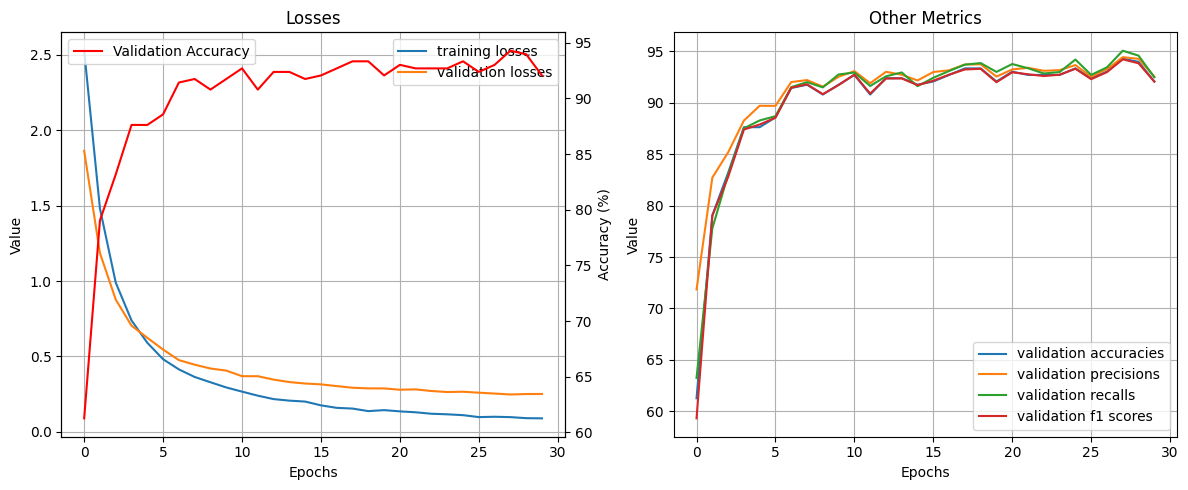

In [ ]:
visualize(metrics)

### Evaluating on the Test Set
The model appears to have trained really well and converged at around 92% accuracy. We can now check how this behaves on the actual test set.

In [ ]:
def test(model, test_loader):
  # Test loop
  model.eval()
  test_loss = 0.0
  correct = 0
  total = 0
  true_labels = []
  predicted_labels = []
  with torch.no_grad():
      for images, labels in test_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          loss = criterion(outputs, labels)
          test_loss += loss.item()
          _, predicted = torch.max(outputs.data, 1)

          true_labels.extend(labels.cpu().numpy())
          predicted_labels.extend(predicted.cpu().numpy())

  # Calculate metrics
  accuracy = 100*accuracy_score(true_labels, predicted_labels)
  precision = 100*precision_score(true_labels, predicted_labels, average='weighted', zero_division=1)
  recall = 100*recall_score(true_labels, predicted_labels, average='weighted')
  f1 = 100*f1_score(true_labels, predicted_labels, average='weighted')

  # Update progress bar with stats
  print(f'Accuracy: {accuracy:.2f}%, Precision: {precision:.2f}%, Recall: {recall:.2f}%, F1 Score: {f1:.2f}%')

In [ ]:
test(resnet18, test_loader)

Accuracy: 93.33%, Precision: 93.81%, Recall: 93.33%, F1 Score: 93.46%


All the metrics are just above 93%! This shows the power of transfer learning.

## What Happens if we Unfreeze All Layers
In the previous model, we froze all layers except the last two fully connected classification layers. This has advantages as it prevents overfitting on the relatively small data set we have (2000 images is nothing compared to the millions that ResNet trained on). For the sake of experimentation, we can see what happens if we retrain it with all parameters unfrozen.

In [ ]:
# Load the ResNet-18 model
resnet18_2 = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)  # This ensures we load the pretrained weights

# We need to know the number of features in the last layer of the pretrained model to adapt our classifier.
# These are equal to the number of inputs of the "fully connected" (fc) head of the ResNet-18.
num_ftrs = resnet18_2.fc.in_features

# Modify the fully connected layer to match the number of classes for the land use identification case study
num_classes = 21
resnet18_2.fc = nn.Linear(num_ftrs, num_classes)
num_outputs = resnet18_2.fc.out_features
print(f"The modified ResNet-18 predicts {num_outputs} classes")

# Check that all are unfrozen
for param in resnet18_2.parameters():
  print(param.requires_grad)

resnet18_2 = resnet18_2.to(device)

The modified ResNet-18 predicts 21 classes
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [ ]:
metrics2 = train(resnet18_2, train_loader, lr=0.001, num_epochs=30)
# Load the best model after training is complete
resnet18_2.load_state_dict(torch.load('/best_model.pth'))
print("Loaded best model from:", '/best_model.pth')

Epoch 1: Improved validation accuracy to 56.83%. Model saved.
Epoch 1/30 Train Loss: 0.8673, Validation Loss: 2.7764, Accuracy: 56.83%
Epoch 2: Improved validation accuracy to 73.65%. Model saved.
Epoch 2/30 Train Loss: 0.3596, Validation Loss: 0.8743, Accuracy: 73.65%
Epoch 3: Improved validation accuracy to 78.41%. Model saved.
Epoch 3/30 Train Loss: 0.2008, Validation Loss: 0.8814, Accuracy: 78.41%
Epoch 4: Improved validation accuracy to 85.40%. Model saved.
Epoch 4/30 Train Loss: 0.1702, Validation Loss: 0.4905, Accuracy: 85.40%
Epoch 5: Improved validation accuracy to 89.52%. Model saved.
Epoch 5/30 Train Loss: 0.0943, Validation Loss: 0.3413, Accuracy: 89.52%
Epoch 6/30 Train Loss: 0.0881, Validation Loss: 0.5780, Accuracy: 85.08%
Epoch 7: Improved validation accuracy to 91.75%. Model saved.
Epoch 7/30 Train Loss: 0.0767, Validation Loss: 0.2959, Accuracy: 91.75%
Epoch 8/30 Train Loss: 0.0980, Validation Loss: 0.3568, Accuracy: 89.84%
Epoch 9/30 Train Loss: 0.0717, Validation Lo

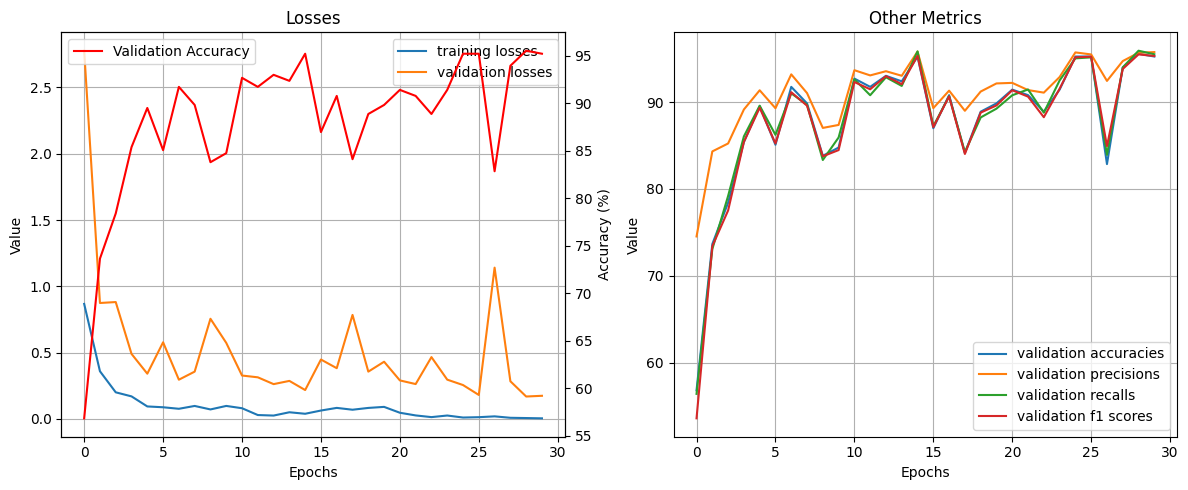

In [ ]:
visualize(metrics2)

In [ ]:
test(resnet18_2, test_loader)

Accuracy: 96.19%, Precision: 96.78%, Recall: 96.19%, F1 Score: 96.02%


### Analysis
We can see that we achieved higher values on all metrics, now just above 96%. This is a fantastic improvement, but it came at the cost of computational resources, and at a great risk of overfitting. However, unfreezing all layers does give us the ability to capture more complex patterns unique to our dataset, so there are some reasons that accuracy went up.

In [ ]:
def test_compare_models(model1, model2, test_loader):
    model1.eval()
    test_loss1 = 0.0
    correct1 = 0
    total1 = 0
    true_labels1 = []
    predicted_labels1 = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model1(images)
            loss = criterion(outputs, labels)
            test_loss1 += loss.item()
            _, predicted = torch.max(outputs.data, 1)

            true_labels1.extend(labels.cpu().numpy())
            predicted_labels1.extend(predicted.cpu().numpy())

    model2.eval()
    test_loss2 = 0.0
    correct2 = 0
    total2 = 0
    true_labels2 = []
    predicted_labels2 = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model2(images)
            loss = criterion(outputs, labels)
            test_loss2 += loss.item()
            _, predicted = torch.max(outputs.data, 1)

            true_labels2.extend(labels.cpu().numpy())
            predicted_labels2.extend(predicted.cpu().numpy())

    # Calculate metrics
    accuracy1 = 100*accuracy_score(true_labels1, predicted_labels1)
    precision1 = 100*precision_score(true_labels1, predicted_labels1, average='weighted', zero_division=1)
    recall1 = 100*recall_score(true_labels1, predicted_labels1, average='macro', zero_division=1)
    f11 = 100*f1_score(true_labels1, predicted_labels1, average='weighted')

    accuracy2 = 100*accuracy_score(true_labels2, predicted_labels2)
    precision2 = 100*precision_score(true_labels2, predicted_labels2, average='weighted', zero_division=1)
    recall2 = 100*recall_score(true_labels2, predicted_labels2, average='macro', zero_division=1)
    f12 = 100*f1_score(true_labels2, predicted_labels2, average='weighted')

    # Calculate gain in metrics for model 2
    accuracy_gain = accuracy2 - accuracy1
    precision_gain = precision2 - precision1
    recall_gain = recall2 - recall1
    f1_gain = f12 - f11

    # Create bar chart comparing metric gains
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    gains = [accuracy_gain, precision_gain, recall_gain, f1_gain]
    values1 = [accuracy1, precision1, recall1, f11]
    values2 = [accuracy2, precision2, recall2, f12]

    bar_width = 0.35
    x = np.arange(len(metrics))

    plt.figure(figsize=(8, 6))
    plt.bar(x - bar_width/2, values1, bar_width, label='Model 1', color='blue')
    plt.bar(x + bar_width/2, values2, bar_width, label='Model 2', color='green')

    plt.xlabel('Metrics')
    plt.ylabel('Value (%)')
    plt.title('Model 1 vs Model 2')

    for i, diff in enumerate(gains):
        plt.text(i - 0.1, max(values1[i], values2[i]) + 1, f'Diff: {diff:.2f}%', color='black')

    plt.xticks(x, metrics)
    plt.legend()
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

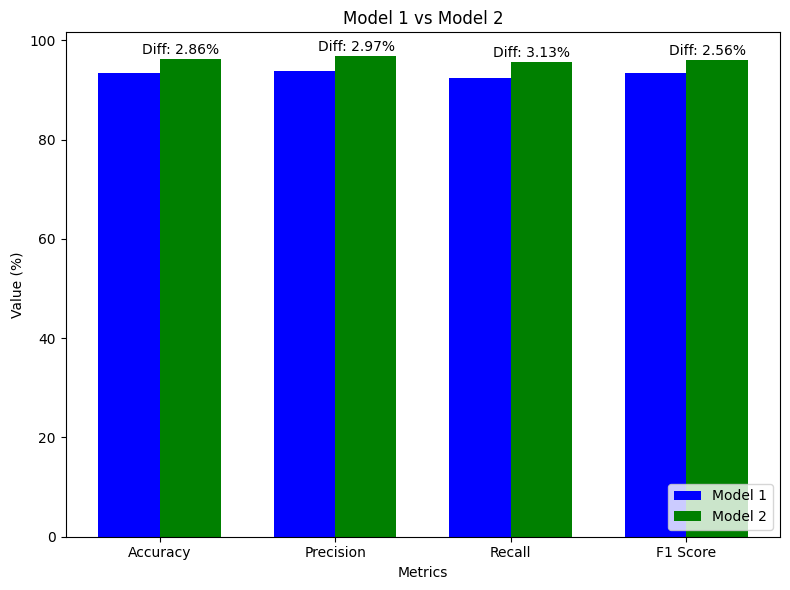

In [ ]:
test_compare_models(resnet18, resnet18_2, test_loader)

## Comparing to Part 1
We can now see just how good transfer learning is by comparing it to the model from part 1.

In [ ]:
class Part1CNN(nn.Module):
    def __init__(self, num_classes):
        super(Part1CNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv7 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv8 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv9 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv10 = nn.Conv2d(512, 512, kernel_size=3, padding=1)

        # Pooling layers
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # MLP classifier
        self.fc = nn.Linear(512 * 7 * 7, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x)

        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        x = self.pool(x)

        x = F.relu(self.conv7(x))
        x = F.relu(self.conv8(x))
        x = self.pool(x)

        x = F.relu(self.conv9(x))
        x = F.relu(self.conv10(x))
        x = self.pool(x)

        x = x.view(-1, 512 * 7 * 7)  # Flatten the tensor

        x = self.fc(x)

        return x

In [ ]:
part_1_CNN = Part1CNN(num_classes=num_classes).to(device)
metrics3 = train(part_1_CNN, train_loader, lr=0.00005, num_epochs=20)
part_1_CNN.load_state_dict(torch.load('/best_model.pth'))
print("Loaded best model from:", '/best_model.pth')

Epoch 1: Improved validation accuracy to 4.44%. Model saved.
Epoch 1/20 Train Loss: 3.0453, Validation Loss: 3.0478, Accuracy: 4.44%
Epoch 2: Improved validation accuracy to 6.67%. Model saved.
Epoch 2/20 Train Loss: 3.0185, Validation Loss: 2.9494, Accuracy: 6.67%
Epoch 3: Improved validation accuracy to 17.78%. Model saved.
Epoch 3/20 Train Loss: 2.8224, Validation Loss: 2.7274, Accuracy: 17.78%
Epoch 4: Improved validation accuracy to 20.32%. Model saved.
Epoch 4/20 Train Loss: 2.5897, Validation Loss: 2.5347, Accuracy: 20.32%
Epoch 5: Improved validation accuracy to 26.03%. Model saved.
Epoch 5/20 Train Loss: 2.3724, Validation Loss: 2.4300, Accuracy: 26.03%
Epoch 6: Improved validation accuracy to 31.75%. Model saved.
Epoch 6/20 Train Loss: 2.1554, Validation Loss: 2.1807, Accuracy: 31.75%
Epoch 7/20 Train Loss: 1.9554, Validation Loss: 2.1416, Accuracy: 29.84%
Epoch 8: Improved validation accuracy to 38.73%. Model saved.
Epoch 8/20 Train Loss: 1.7215, Validation Loss: 2.0182, Acc

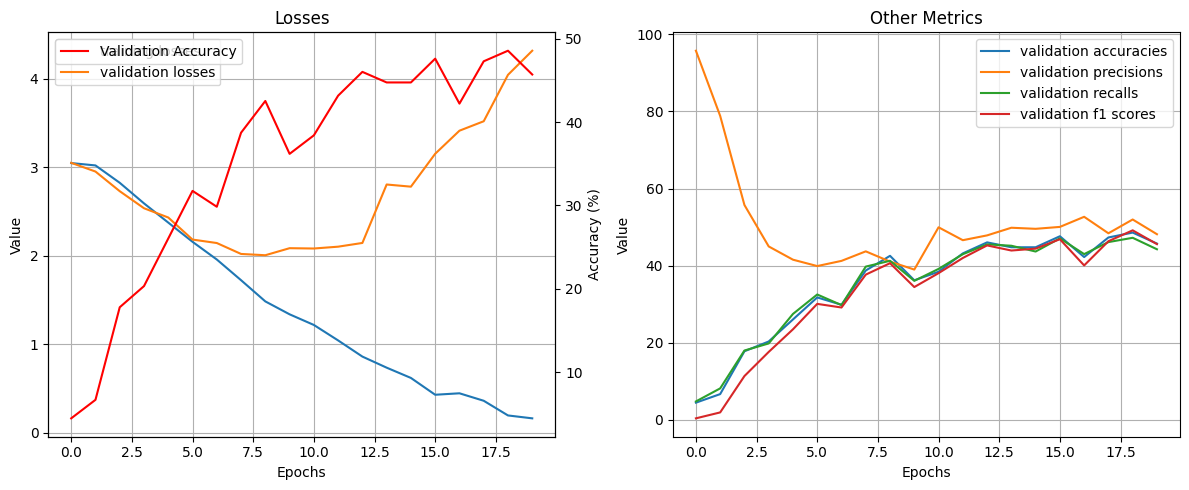

In [ ]:
visualize(metrics3)

In [ ]:
test(part_1_CNN, test_loader)

Accuracy: 52.06%, Precision: 55.02%, Recall: 52.06%, F1 Score: 52.46%


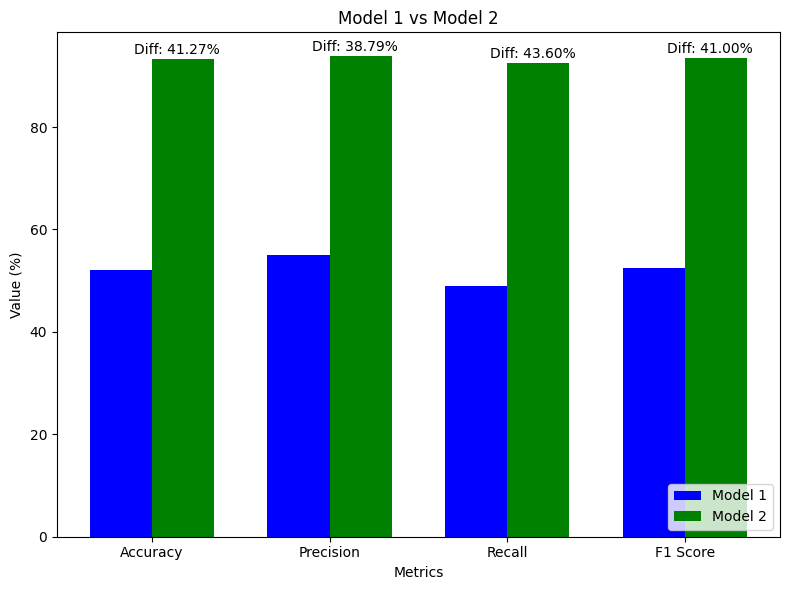

In [ ]:
test_compare_models(part_1_CNN, resnet18, test_loader)

Transfer learning is quite powerful as we can see!